In [23]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
con=sqlite3.connect('C:\\Users\\yasee\\OneDrive\\Desktop\\Sem 3 projects\\project 3.1\\data\\raw\\ipl.db')

def q(sql):
    return pd.read_sql(sql,con)

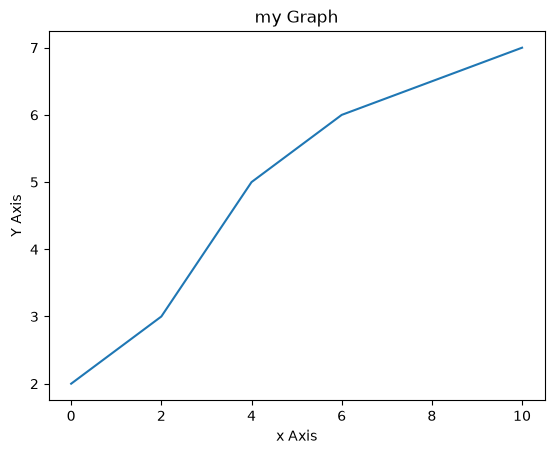

In [24]:
x=[0,2,4,6,10]
y=[2,3,5,6,7]

plt.plot(x,y)
plt.title("my Graph")
plt.xlabel("x Axis")
plt.ylabel("Y Axis")
plt.show()


<Axes: title={'center': 'Total balls in Each phases'}, xlabel='different phases of innings', ylabel='total number of balls'>

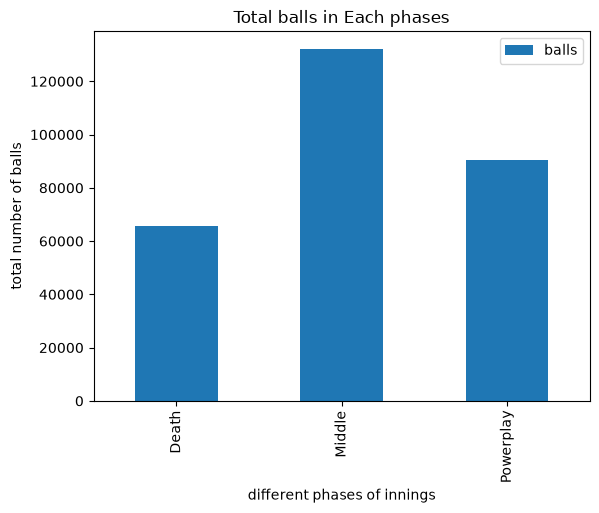

In [25]:
df=pd.read_sql("""SELECT phase, COUNT(*) AS balls FROM v_ball GROUP BY phase; """,con)
df.plot(kind="bar",
        x="phase",
        y="balls",
        title="Total balls in Each phases",
        xlabel="different phases of innings",
        ylabel="total number of balls")

In [26]:
q(""" 
--Higest ball faced by a player,total runs,strike rate

SELECT batter,
            SUM(is_legal)  AS balls,
            SUM(batter_runs)AS runs,
            ROUND(100.0 * SUM (batter_runs)/SUM(is_legal),2) AS strike_rate

 FROM v_ball
 GROUP BY batter
 ORDER BY BALLS DESC
 LIMIT 10;
 """)

,batter,balls,runs,strike_rate
0,V Kohli,6730,9040,134.32
1,RG Sharma,5396,7183,133.12
2,S Dhawan,5302,6769,127.67
3,DA Warner,4675,6565,140.43
4,AM Rahane,4141,5194,125.43
5,KL Rahul,4059,5655,139.32
6,SK Raina,4022,5528,137.44
7,MS Dhoni,3935,5439,138.22
8,RV Uthappa,3782,4952,130.94
9,KD Karthik,3567,4842,135.74


<Axes: title={'center': 'highest ball faced by a player'}, xlabel='total number of runs', ylabel='total number of balls'>

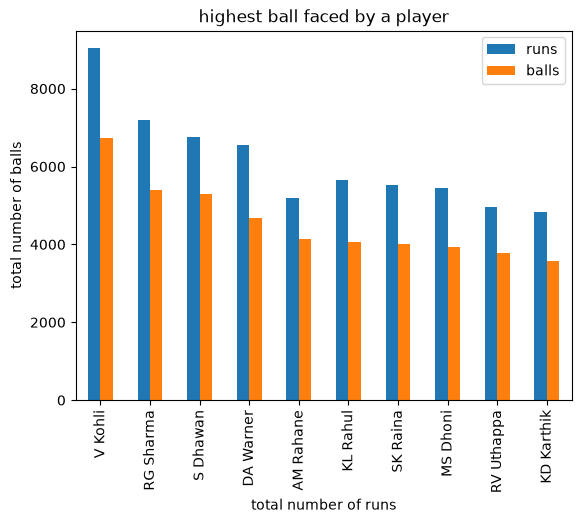

In [35]:
df=pd.read_sql("""SELECT batter,
            SUM(is_legal)  AS balls,
            SUM(batter_runs)AS runs,
            ROUND(100.0 * SUM (batter_runs)/SUM(is_legal),2) AS strike_rate

 FROM v_ball
 GROUP BY batter
 ORDER BY BALLS DESC
 LIMIT 10;
 """,con)
df.plot(kind="bar",
        x="batter",
        y=["runs","balls"],
        title="highest ball faced by a player",
        xlabel="total number of runs",
        ylabel="total number of balls")


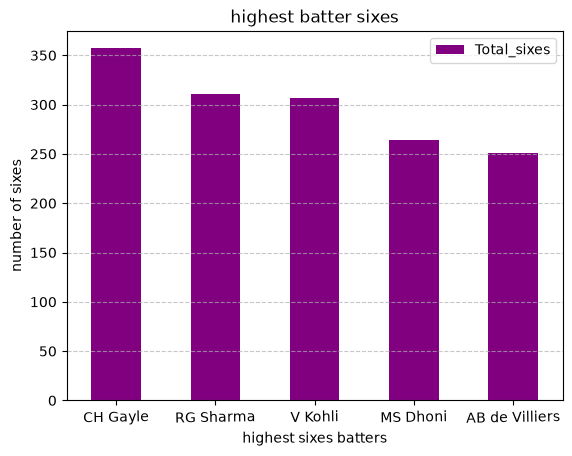

In [38]:
df=pd.read_sql("""select batter ,
       SUM(CASE WHEN batter_runs=6
           THEN 1
           ELSE 0
           END) AS Total_sixes
FROM v_ball
GROUP BY batter
ORDER BY total_sixes DESC
LIMIT 5; """,con)
df.plot(kind="bar",
        x="batter",
        y="Total_sixes",
        color="purple",
        title="highest batter sixes",
        xlabel="highest sixes batters",
        ylabel="number of sixes")
plt.xticks(rotation=1)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [57]:
q("""
SELECT 
    bowler,
    SUM(bowler_wicket) AS wicket
FROM v_ball
GROUP BY bowler
ORDER BY wicket DESC
LIMIT 10; """)

,bowler,wicket
0,YS Chahal,228
1,B Kumar,215
2,SP Narine,199
3,PP Chawla,192
4,R Ashwin,187
5,JJ Bumrah,185
6,DJ Bravo,183
7,RA Jadeja,177
8,A Mishra,174
9,SL Malinga,170


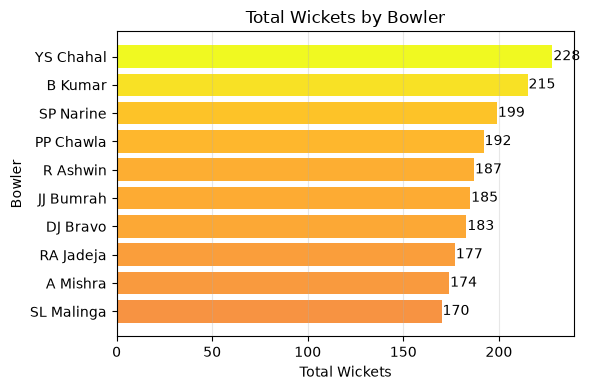

In [56]:
af= pd.read_sql("""
SELECT 
    bowler,
    SUM(bowler_wicket) AS wicket
FROM v_ball
GROUP BY bowler
ORDER BY wicket DESC
LIMIT 10; """, con)

plt.figure(figsize=(6, 4))

colors = plt.cm.plasma(
    af["wicket"] / af["wicket"].max()
)

bars = plt.barh(
    af["bowler"],
    af["wicket"],
    color=colors
)

plt.xlabel("Total Wickets")
plt.ylabel("Bowler")
plt.title("Total Wickets by Bowler")

plt.gca().invert_yaxis()

# Add wicket values
for bar in bars:
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        int(bar.get_width()),
        va="center"
    )

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:
q("""
SELECT 
    batter,
    SUM(
        CASE 
            WHEN batter_runs = 6 THEN 1
            ELSE 0
        END
    ) AS total_sixes
FROM v_ball
GROUP BY batter
ORDER BY total_sixes DESC
LIMIT 10;
""")

,batter,total_sixes
0,CH Gayle,357
1,RG Sharma,311
2,V Kohli,307
3,MS Dhoni,264
4,AB de Villiers,251
5,DA Warner,236
6,SV Samson,234
7,KL Rahul,232
8,AD Russell,223
9,KA Pollard,223


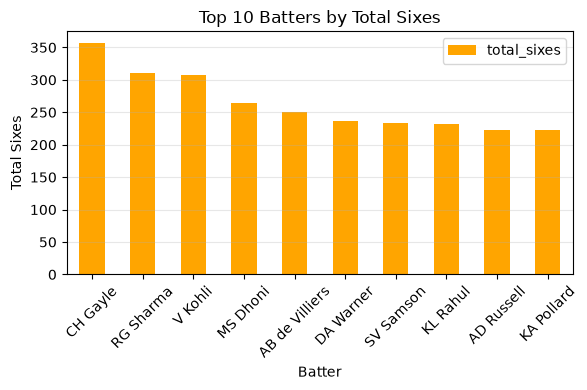

In [60]:
df= pd.read_sql("""
SELECT 
    batter,
    SUM(
        CASE 
            WHEN batter_runs = 6 THEN 1
            ELSE 0
        END
    ) AS total_sixes
FROM v_ball
GROUP BY batter
ORDER BY total_sixes DESC
LIMIT 10;
""", con)

ac.plot(
    kind="bar",
    x="batter",
    y="total_sixes",
    title="Top 10 Batters by Total Sixes",
    xlabel="Batter",
    ylabel="Total Sixes",
    color="orange",
    figsize=(6, 4)
)

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
q("""
SELECT
    toss_winner,
    COUNT(*) AS toss_won
FROM matches_clean
GROUP BY toss_winner
ORDER BY toss_won DESC;
""")


,toss_winner,toss_won
0,Mumbai Indians,156
1,Delhi Capitals,145
2,Sunrisers Hyderabad,139
3,Rajasthan Royals,134
4,Royal Challengers Bangalore,132
5,Kolkata Knight Riders,132
6,Chennai Super Kings,130
7,Punjab Kings,126
8,Gujarat Titans,33
9,Lucknow Super Giants,29


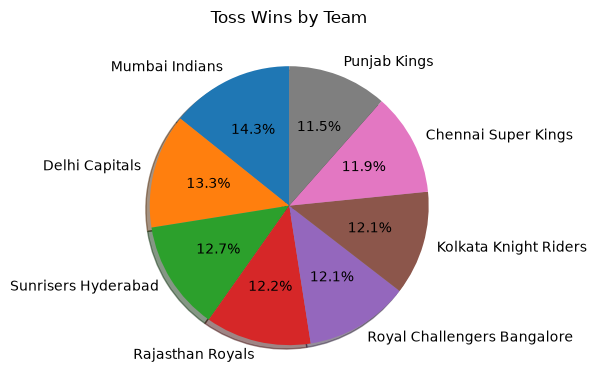

In [59]:
ag = pd.read_sql("""
SELECT
    toss_winner,
    COUNT(*) AS toss_won
FROM matches_clean
GROUP BY toss_winner
ORDER BY toss_won DESC
LIMIT 8;
""", con)

plt.figure(figsize=(6, 4))

plt.pie(
    ag["toss_won"],
    labels=ag["toss_winner"],
    autopct="%1.1f%%",
    startangle=90,
    shadow=True
)

plt.title("Toss Wins by Team")

plt.tight_layout()
plt.show()

In [49]:
q("""
SELECT 
    batter,
    SUM(batter_runs) AS runs,
    SUM(CASE WHEN is_legal = 1 THEN 1 ELSE 0 END) AS balls,
    ROUND(
        100.0 * SUM(batter_runs) /
        SUM(CASE WHEN is_legal = 1 THEN 1 ELSE 0 END),
        2
    ) AS strike_rate
FROM v_ball
WHERE phase = 'Powerplay'
GROUP BY batter
HAVING SUM(CASE WHEN is_legal = 1 THEN 1 ELSE 0 END) >= 100
ORDER BY strike_rate DESC
LIMIT 10;
""")

,batter,runs,balls,strike_rate
0,V Suryavanshi,467,202,231.19
1,J Fraser-McGurk,298,142,209.86
2,Priyansh Arya,603,301,200.33
3,A Mhatre,275,145,189.66
4,TM Head,884,493,179.31
5,P Nissanka,185,104,177.88
6,PD Salt,840,484,173.55
7,Abhishek Sharma,1287,744,172.98
8,SP Narine,1174,688,170.64
9,YBK Jaiswal,1579,984,160.47


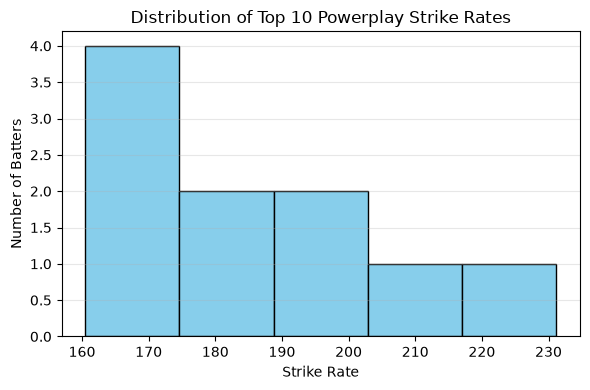

In [51]:
ad = pd.read_sql("""
SELECT 
    batter,
    SUM(batter_runs) AS runs,
    SUM(CASE WHEN is_legal = 1 THEN 1 ELSE 0 END) AS balls,
    ROUND(
        100.0 * SUM(batter_runs) /
        SUM(CASE WHEN is_legal = 1 THEN 1 ELSE 0 END),
        2
    ) AS strike_rate
FROM v_ball
WHERE phase = 'Powerplay'
GROUP BY batter
HAVING SUM(CASE WHEN is_legal = 1 THEN 1 ELSE 0 END) >= 100
ORDER BY strike_rate DESC
LIMIT 10;
""", con)

plt.figure(figsize=(6, 4))

plt.hist(
    ad["strike_rate"],
    bins=5,
    color="skyblue",
    edgecolor="black"
)

plt.title("Distribution of Top 10 Powerplay Strike Rates")
plt.xlabel("Strike Rate")
plt.ylabel("Number of Batters")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()